# Low-Dose Simulation: Impact of Noise on Image Quality and Segmentation

## 1 Objective

This notebook investigates how reduced radiation dose affects image quality and downstream vessel segmentation in X-ray angiography.

Building on the clean-image baseline established previously, we introduce controlled Poisson noise to simulate low-dose acquisition and evaluate its impact on:

- **Background SNR** → noise level  
- **CNR** → vessel-background separability  
- **Dice score** → segmentation performance  

The goal is to quantify degradation due to noise and identify the regime where segmentation begins to fail.

## 2 Motivation

Reducing radiation dose is essential for minimizing patient exposure, but it introduces quantum noise due to reduced photon counts.

This noise degrades image quality and may impair the visibility of vessel structures, particularly smaller or low-contrast regions.

Understanding how segmentation performance degrades with dose is critical for assessing the limits of current pipelines and motivating the use of denoising methods.

## 3.1 Low-Dose Simulation

Low-dose conditions are simulated using a Poisson noise model, which approximates photon-counting statistics in X-ray imaging.

For each image, the expected photon count is scaled by a dose factor and noise is introduced via Poisson sampling:


  * **100% (clean reference)**
  * **50% (mild noise)**
  * **25% (moderate noise)**
  * **10% (strong noise)**
  * **5% (very strong noise, likely the limit for interpretability)**

This approximates photon-counting statistics in X-ray imaging, where lower dose leads to increased noise variance. Noise simulation is applied in image space as an approximation; exact physical simulation would require inverting the scanner processing pipeline which is unavailable.

## 3.2 Noise Simulation

To ensure consistent noise across all experiments, low-dose images are generated once and saved to disk rather than simulated on the fly. Each call to `reduce_dose` draws a different Poisson noise realisation, so generating images at runtime would produce different noise in threshold optimisation, metric evaluation, and U-Net training — making comparisons unreliable.

Images are saved as 16-bit PNG to preserve the float32 precision of the noise, and loaded back with `cv2.IMREAD_UNCHANGED`. To regenerate, run `scripts/generate_noisy_dataset.py`.


In [1]:

from pathlib import Path
import sys
sys.path.append('..')

import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
np.random.seed(42)

params_file = Path("../algorithms/frangi_dice_params.json")
saved_params = json.loads(params_file.read_text()) if params_file.exists() else {}
scale_range = saved_params.get("scale_range", [5.0, 10.0])
gamma = saved_params.get("gamma", 2.0)
fixed_threshold = saved_params.get("threshold", 0.15) 
dilate_radius = saved_params.get("dilate_radius", 1)

import importlib
import algorithms.dose_reduction
importlib.reload(algorithms.dose_reduction)
from datasets.arcade_dataset import ArcadeDataset, Sample
from algorithms.dose_reduction import load_noisy
from algorithms.frangi import apply_frangi
from metrics.dice import compute_dice
from metrics.snr_cnr import compute_snr_cnr

## 4 Experimental Setup

To isolate the effect of noise, the segmentation pipeline is kept fixed across all dose levels.

The pipeline consists of:
- Frangi vesselness filtering  
- Thresholding  
- Morphological dilation  

Parameters are optimized on clean images and not re-tuned for noisy data.  

In [2]:
from IPython.display import Markdown, display
display(Markdown(
    f"* Scale range* : {scale_range} \n"
    f"* Gamma* : {gamma} \n"
    f"* Threshold* : {fixed_threshold} \n"
    f"* Dilation radius* : {dilate_radius} \n"
))

doses = [1.0, 0.5, 0.25, 0.1, 0.05]

* Scale range* : [5.0, 10.0] 
* Gamma* : 2.0 
* Threshold* : 0.1 
* Dilation radius* : 1 


This ensures that any performance changes are caused by noise rather than parameter adaptation.

Metrics are computed using predefined regions of interest:
- Vessel region (ground truth mask)  
- Background region (excluding dilated vessels and frame artefacts)


## 5 Visual Effect of Dose Reduction

Example images at different dose levels illustrate the effect of increasing noise.

As dose decreases:
- background becomes progressively noisier  
- vessel contrast is reduced  
- small vessels become less visible  

Frangi-based segmentation results are overlaid to highlight how these changes affect vessel detection.

In [3]:
import textwrap

def plot_reduced_dose(ax, sample, dose, width):
    
    image = load_noisy(sample.path.name, f = dose)
    frangi_vessel = apply_frangi(image, scale_range=scale_range, gamma = gamma)
    precision, recall, dice, pred = compute_dice(frangi_vessel, sample.mask, return_map=True, dilate_radius=dilate_radius, threshold=fixed_threshold)
    image_quality = compute_snr_cnr(image, sample.mask)
    
    ax.set_title(textwrap.fill(f"Image for dose = {dose} + binary Frangi mask (red)", width))

    #ax.set_title(f"Image for dose = {dose} + binary Frangi mask (red)", wrap = True)
    
    ax.imshow(image, cmap = "grey")
    pred_overlay = np.zeros((*sample.image.shape, 4))
    pred_overlay[pred == 1] = [1, 0, 0, 0.3]  # red, semi-transparent
    ax.imshow(pred_overlay)
    ax.text(0.5, -0.05, f"SNR={image_quality["snr"]:.2f}, CNR={image_quality["cnr"]:.2f}\n"
              f"Dice score={dice:.2f}, Precision={precision:.2f}, Recall={recall:.2f}", 
              transform=ax.transAxes, ha="center", va="top")
    ax.axis('off')

def plot_dose(filename, sample, part = "a"):
    
    fig, axes = plt.subplots(1, len(doses), figsize=(22, 5))
    fig.suptitle(f"Figure 1{part}. Simulated dose reduction for sample {filename} with segmentation overlay", fontsize=14) 
    width = int(fig.get_size_inches()[0] / len(doses) * 8)

    #plot_reduced_dose(sample=sample, dose = 1.0, ax = axes[0])

    for i, dose in enumerate(doses): 
        plot_reduced_dose(sample=sample, dose = dose, ax = axes[i], width = width)
    
    vessel_overlay = np.zeros((*sample.image.shape, 4))
    vessel_overlay[sample.mask == 1] = [0, 0, 1, 0.3]  # blue, semi-transparent
    axes[0].imshow(vessel_overlay)
    axes[0].set_title(textwrap.fill(f"Image + binary Frangi mask (red) + GT mask (blue)", width))
    
    plt.show()

In [4]:
dataset = ArcadeDataset(root_dir="../data", split="val")
print(len(dataset), dataset[0].image.shape, dataset[0].mask.shape)
idx = np.random.randint(0, len(dataset))
sample = dataset[idx]
filename = Path(sample.path).name
# filename2= "124.png"
filename2 = "101.png"
sample2 = dataset.get_by_filename(filename2)
# filename3 = "96.png"
filename3 = "81.png"
sample3 = dataset.get_by_filename(filename3)

195 (512, 512) (512, 512)


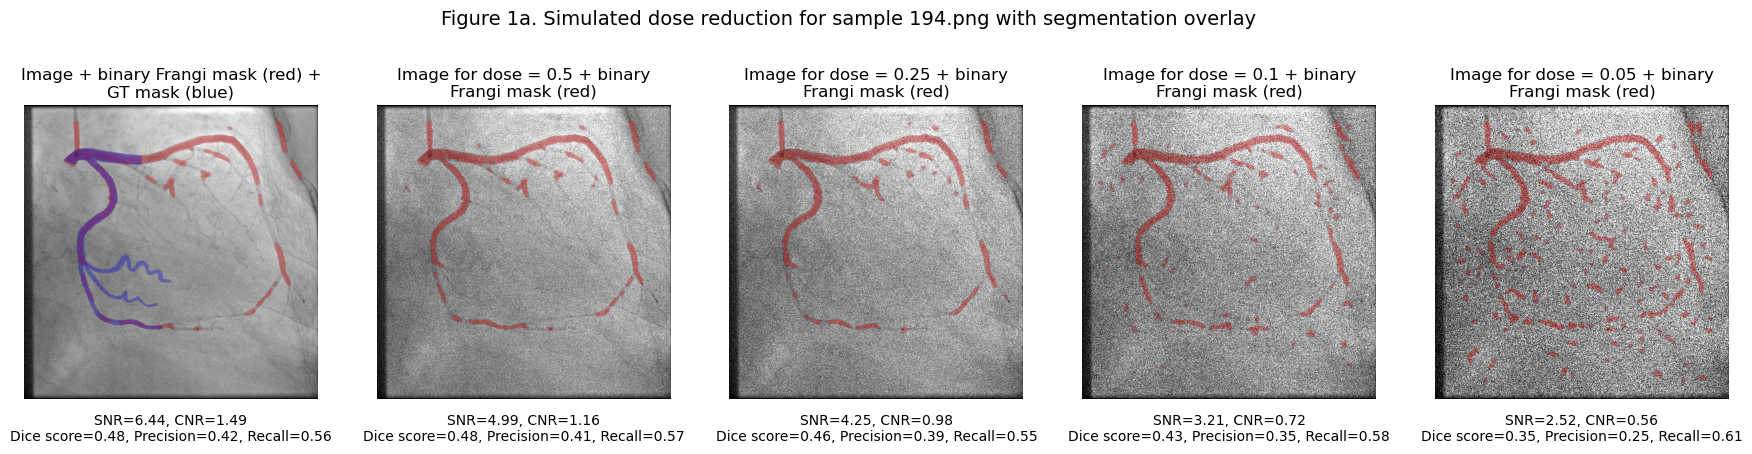

In [5]:
plot_dose(filename, sample, part="a")

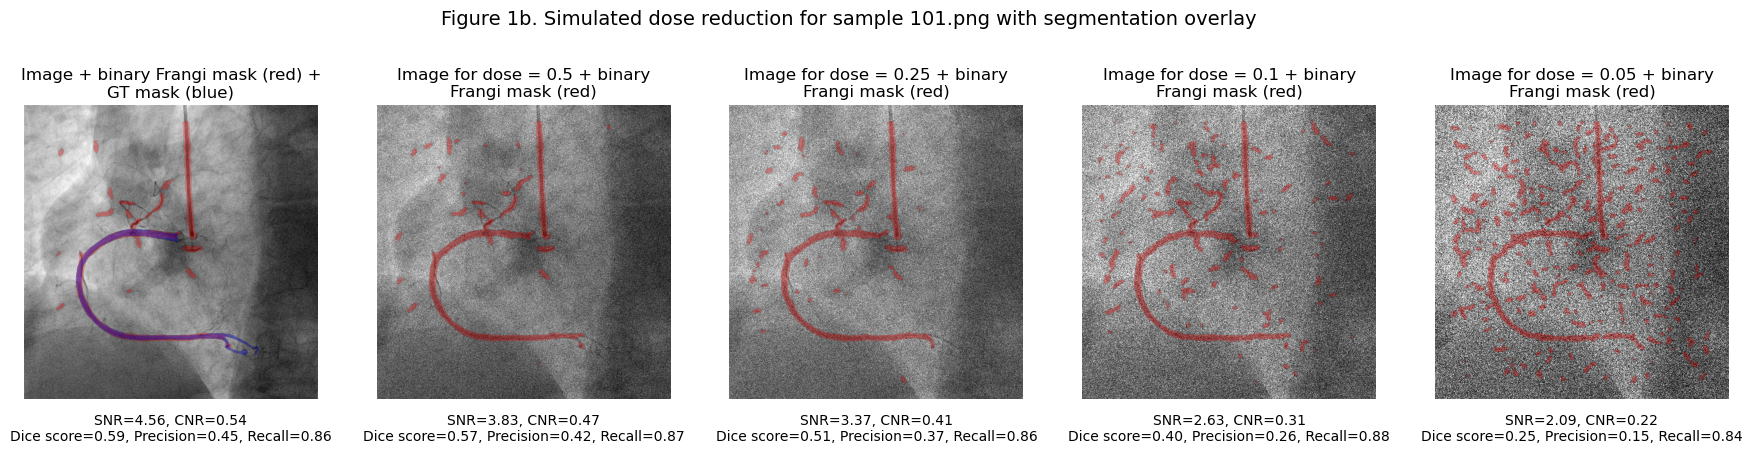

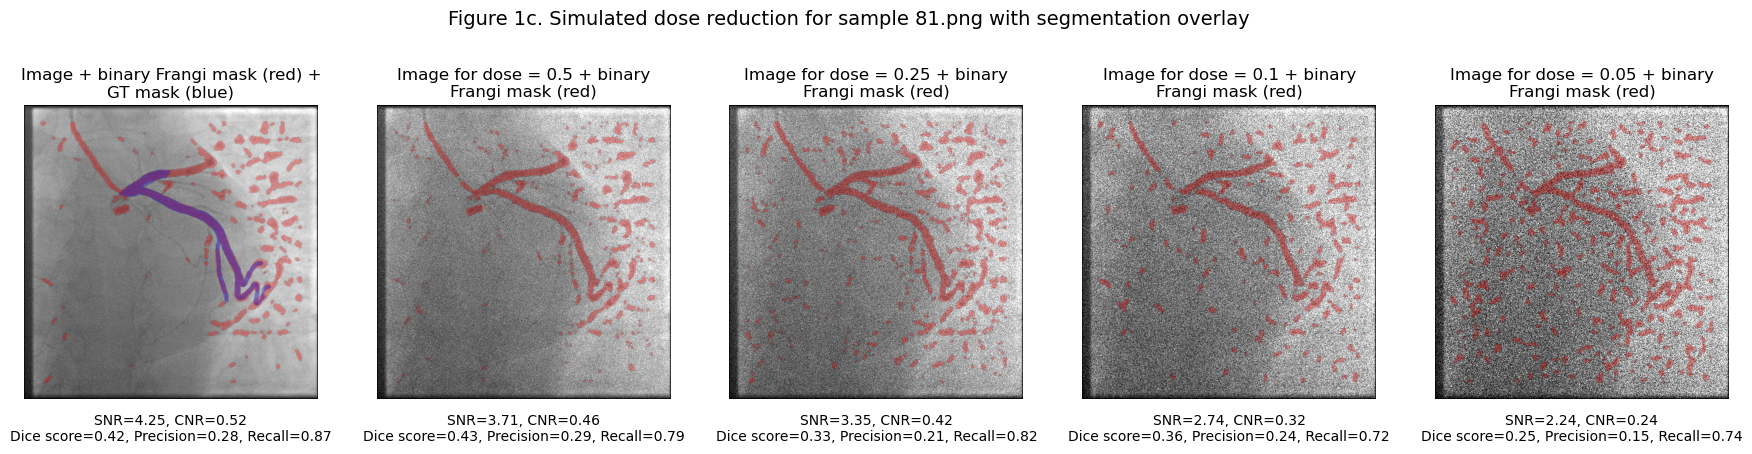

In [6]:
plot_dose(filename2, sample2, part="b")
plot_dose(filename3, sample3, part="c")

## 6 Quantitative Degradation with Dose

## 6.1 Image Quality Degradation

Image quality is quantified using:

- Background SNR (mean(background) / std(background))  
- CNR (contrast-to-noise ratio between vessel and background)

Both metrics decrease with dose, reflecting:
- increased noise levels  
- reduced vessel-background separability  

This indicates that vessel detection becomes increasingly challenging under low-dose conditions.

## 6.2 Segmentation Performance

Segmentation performance is evaluated using the Dice coefficient.

Results show that:
- Dice remains relatively stable across moderate noise levels  
- a sharp degradation occurs at strong noise levels (e.g., 5%)

This suggests that the segmentation pipeline is robust to moderate noise but fails beyond a critical threshold.

In [7]:

from tqdm import tqdm

rows = []
for sample in tqdm(dataset):
    for f in doses:
        image = load_noisy(sample.path.name, f)
        snr_cnr = compute_snr_cnr(image, sample.mask)
        vesselness = apply_frangi(image)
        precision, recall, dice = compute_dice(vesselness, sample.mask, dilate_radius=dilate_radius, threshold=fixed_threshold)
        rows.append({
            "filename": sample.path.name,
            "dose": f,
            "snr": snr_cnr["snr"],
            "cnr": snr_cnr["cnr"],
            "dice": dice,
            "precision": precision,
            "recall": recall,
        })

df = pd.DataFrame(rows)
df.to_csv("../results/noisy_metrics_baseline.csv", index=False)
df.head()


100%|██████████| 195/195 [16:20<00:00,  5.03s/it]


,filename,dose,snr,cnr,dice,precision,recall
0,1.png,1.00,5.296054,1.119535,0.577205,0.503179,0.676770
1,1.png,0.50,4.323840,0.911785,0.562961,0.488538,0.664133
2,1.png,0.25,3.766492,0.789418,0.561789,0.479632,0.677910
3,1.png,0.10,2.916952,0.605623,0.539244,0.443505,0.687696
4,1.png,0.05,2.311552,0.471071,0.453055,0.327463,0.734917


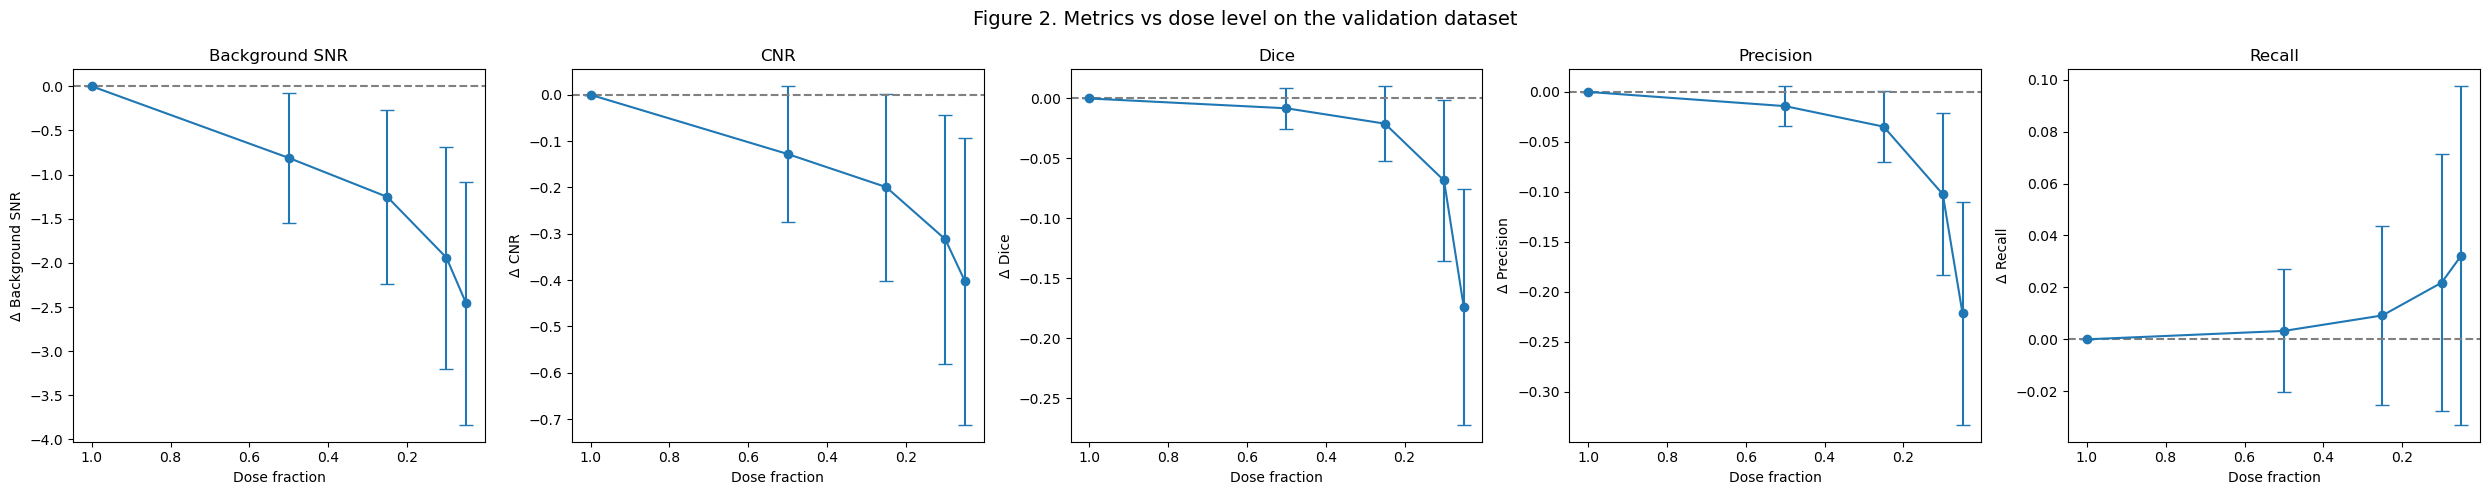

In [8]:
metrics = ["snr", "cnr", "dice", "precision", "recall"]
labels = {"snr": "Background SNR", "cnr": "CNR", "dice": "Dice", "precision": "Precision", "recall": "Recall"}

fig, axes = plt.subplots(1, len(metrics), figsize=(5 * len(metrics), 5))
fig.suptitle("Figure 2. Metrics vs dose level on the validation dataset", fontsize=14)


for ax, metric in zip(axes, metrics):
    baseline = df[df["dose"] == 1.0][metric].values
    means, stds = [], []
    for f in doses:
        diff = df[df["dose"] == f][metric].values - baseline
        means.append(diff.mean())
        stds.append(diff.std())
    ax.errorbar(doses, means, yerr=stds, marker="o", capsize=5)
    ax.axhline(0, color="gray", linestyle="--")
    ax.set_title(labels[metric])
    ax.set_xlabel("Dose fraction")
    ax.set_ylabel(f"Δ {labels[metric]}")
    ax.invert_xaxis()


plt.tight_layout()
plt.show()


## 7 Interpretation of Results

* **SNR decreases** with dose due to increased quantum noise
* **CNR decreases**, reducing vessel-background separability
* **Recall** increases with noise as Frangi over-detects, producing a larger mask that covers more ground truth vessels — at the cost of **Precision**, which drops sharply.
* **Dice score drops only for string noise**, indicating degraded overall segmentation performance

The limited degradation at moderate noise levels can be explained by several factors:

- The Frangi filter enhances vessel-like structures across multiple scales  
- Thresholding suppresses weak noise-induced responses  
- Morphological dilation compensates for small discontinuities  
- Ground truth annotations emphasize large vessels, which remain detectable under noise  

As a result, overlap-based metrics such as Dice remain stable despite visible image degradation.

## 8 Sensitivity of Segmentation Parameters to Noise

The main experiments use fixed parameters optimized on clean images.  
However, optimal segmentation parameters are expected to depend on noise level.

To assess this, an auxiliary experiment is performed:

- For each dose level, the threshold parameter is re-optimized on a subset of data (50 randomly selected samples)
- The resulting optimal threshold is analyzed as a function of noise level  

Results show that:
- optimal thresholds shift with increasing noise  
- higher thresholds are required to suppress noise-induced responses  

Comparison of Dice scores with fixed vs optimized thresholds indicates that part of the performance degradation is due to parameter mismatch.

This highlights a limitation of fixed-parameter pipelines under varying acquisition conditions.

In [9]:
thresholds = [0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4]

subset_idx = np.random.choice(len(dataset), size=50, replace=False)
subset = [dataset[i] for i in subset_idx]

dose_thresholds = {}  # dose -> {"threshold": ..., "dice": ...}

from tqdm.notebook import tqdm

for f in tqdm(doses, desc="Doses"):
    best_thresh, best_dice = None, -1
    for thr in tqdm(thresholds, desc=f"Thesholds, dose={f}", position=1, leave=False):
        dice_scores = []
        for sample in tqdm(subset, desc=f"dose={f} thr={thr}", position=1, leave=False):
            image = load_noisy(sample.path.name, f)
            vesselness = apply_frangi(image)
            _, _, dice = compute_dice(vesselness, sample.mask,
                                      threshold=thr, dilate_radius=dilate_radius)
            dice_scores.append(dice)
        mean_dice = np.mean(dice_scores)
        if mean_dice > best_dice:
            best_dice, best_thresh = mean_dice, thr
    dose_thresholds[f] = {"threshold": best_thresh, "dice": best_dice}
    print(f"dose={f}: best threshold={best_thresh}, dice={best_dice:.3f}")

# with open("../algorithms/dose_thresholds.json", "w") as f:
#     json.dump({str(dose): dose_thresholds[dose]["threshold"] for dose in doses}, f, indent=2)

Doses:   0%|          | 0/5 [00:00<?, ?it/s]

Thesholds, dose=1.0:   0%|          | 0/8 [00:00<?, ?it/s]

dose=1.0 thr=0.05:   0%|          | 0/50 [00:00<?, ?it/s]

dose=1.0 thr=0.1:   0%|          | 0/50 [00:00<?, ?it/s]

dose=1.0 thr=0.15:   0%|          | 0/50 [00:00<?, ?it/s]

...

dose=0.05 thr=0.25:   0%|          | 0/50 [00:00<?, ?it/s]

dose=0.05 thr=0.3:   0%|          | 0/50 [00:00<?, ?it/s]

dose=0.05 thr=0.35:   0%|          | 0/50 [00:00<?, ?it/s]

dose=0.05 thr=0.4:   0%|          | 0/50 [00:00<?, ?it/s]

dose=0.05: best threshold=0.2, dice=0.449


In [10]:
opt_dice_per_dose = {}

for f in tqdm(doses, desc="doses"):
    thr = dose_thresholds[f]["threshold"]
    dice_scores = []
    for sample in dataset:
        image = load_noisy(sample.path.name, f)
        vesselness = apply_frangi(image)
        _, _, dice = compute_dice(vesselness, sample.mask,
                                  threshold=thr,
                                  dilate_radius=dilate_radius)
        dice_scores.append(dice)
    opt_dice_per_dose[f] = np.mean(dice_scores)




doses:   0%|          | 0/5 [00:00<?, ?it/s]

In [11]:
with open("../algorithms/dose_thresholds.json", "w") as fh:
    json.dump({
        str(dose): {
            "threshold": dose_thresholds[dose]["threshold"],
            "dice": opt_dice_per_dose[dose],
        }
        for dose in doses
    }, fh, indent=2)


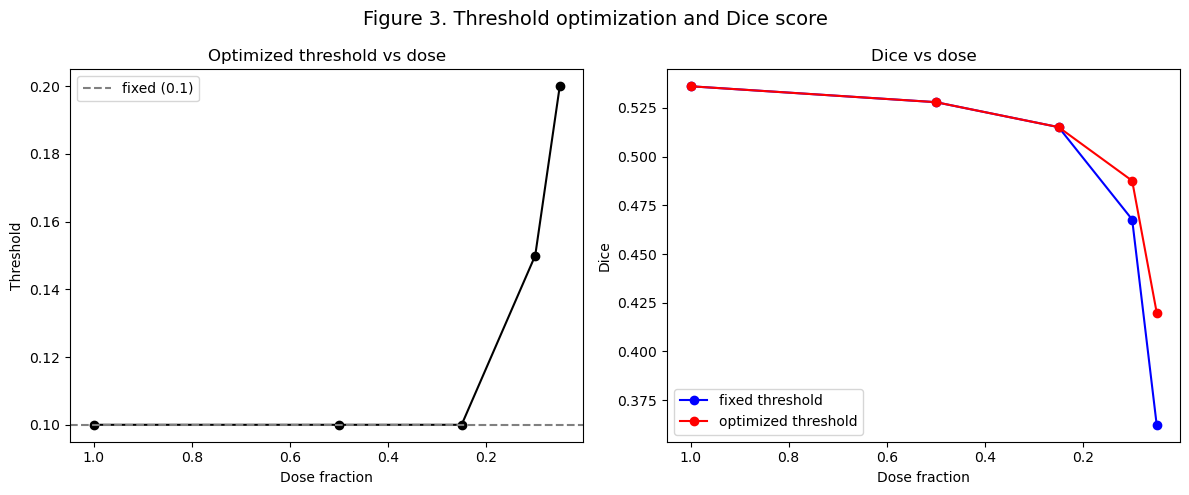

In [12]:
df = pd.read_csv("../results/noisy_metrics_baseline.csv")
with open("../algorithms/dose_thresholds.json") as f:
    dose_thresholds = {float(k): v for k, v in json.load(f).items()}

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Figure 3. Threshold optimization and Dice score", fontsize=14)

# left: optimized threshold vs dose
axes[0].plot(doses, [dose_thresholds[f]["threshold"] for f in doses], marker="o", color="black")
axes[0].axhline(fixed_threshold, color="gray", linestyle="--", label=f"fixed ({fixed_threshold})")
axes[0].set_xlabel("Dose fraction")
axes[0].set_ylabel("Threshold")
axes[0].set_title("Optimized threshold vs dose")
axes[0].invert_xaxis()
axes[0].legend()

# right: dice vs dose
fixed_dice_per_dose = {
    f: df[df["dose"] == f]["dice"].mean() for f in doses
}
axes[1].plot(doses, [fixed_dice_per_dose[f] for f in doses], marker="o", color="blue", label="fixed threshold")
axes[1].plot(doses, [opt_dice_per_dose[f] for f in doses], marker="o", color="red", label="optimized threshold")
axes[1].set_xlabel("Dose fraction")
axes[1].set_ylabel("Dice")
axes[1].set_title("Dice vs dose")
axes[1].invert_xaxis()
axes[1].legend()

plt.tight_layout()
plt.show()


## Summary

This experiment evaluated the sensitivity of Frangi-based vessel segmentation to simulated low-dose noise and parameter tuning.

Key findings:

- Image quality degrades with decreasing dose, reflected in lower background SNR and CNR  
- Segmentation performance (Dice score) decreases with increasing noise, with a sharp drop at very low dose (5%)  
- Re-optimizing the segmentation threshold has no impact across most dose levels
- At extreme noise levels, optimization provides only limited improvement (~0.3 Dice), without restoring performance  

Overall, these results indicate that segmentation degradation is primarily driven by loss of vessel signal and contrast rather than suboptimal parameter settings.

This establishes that improving downstream performance under low-dose conditions requires enhancing image quality, motivating the use of denoising approaches in the next stage.